# Lab 2: K-Nearest Neighbors (KNN) and Radius Neighbors (RNN) Classification

**Name:** Shuyang Tang

**Course:** MSCS 634 — Advanced Data Mining

**Lab Assignment:** Lab 2 — KNN and RNN Classification Using the Wine Dataset

---
## Step 1: Load and Prepare the Dataset

We load the **Wine Dataset** from `sklearn`, which contains **178 wine samples** from three different cultivars (classes), each described by **13 chemical features** such as alcohol content, flavanoids, color intensity, and proline.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(wine.target_names))
print("Class names:", wine.target_names)

Dataset shape: (178, 13)
Number of classes: 3
Class names: ['class_0' 'class_1' 'class_2']


In [2]:
# Basic data exploration — put features into a DataFrame for easy review
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

# Review feature details
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# Summary statistics for each feature
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Class distribution:
  Class 0 (class_0): 59 samples (33.1%)
  Class 1 (class_1): 71 samples (39.9%)
  Class 2 (class_2): 48 samples (27.0%)


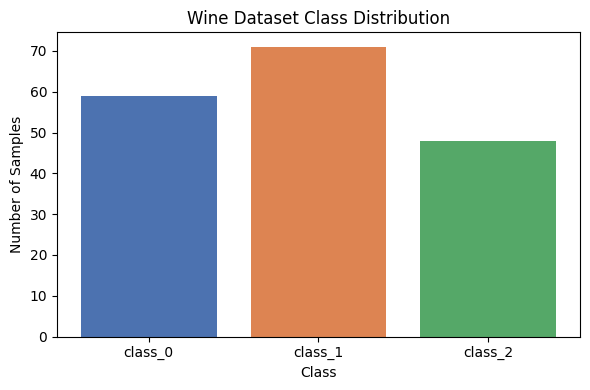

In [4]:
# Class distribution — check for balance
class_counts = pd.Series(y).value_counts().sort_index()
print("Class distribution:")
for cls, count in class_counts.items():
    print(f"  Class {cls} ({wine.target_names[cls]}): {count} samples ({count/len(y)*100:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(6, 4))
plt.bar(wine.target_names, class_counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Wine Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

**Observations from exploration:**
- The dataset has **178 samples, 13 numeric features, and 3 classes** (class_0: 59, class_1: 71, class_2: 48). The classes are reasonably balanced.
- Feature scales vary **enormously** — most features range from roughly 0–30, but `proline` spans **278–1680** and `magnesium` spans 70–162. This scale difference matters a great deal for distance-based classifiers like KNN and RNN, because large-scale features dominate the Euclidean distance. This is also why the lab's radius values (350–600) are in the hundreds — they reflect the scale of `proline`.

In [5]:
# Split the dataset: 80% training, 20% testing
# stratify=y keeps class proportions the same in both splits; random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set:", X_train.shape[0], "samples")
print("Test set:    ", X_test.shape[0], "samples")

Training set: 142 samples
Test set:     36 samples


---
## Step 2: Implement K-Nearest Neighbors (KNN)

We train a `KNeighborsClassifier` for each value of **k ∈ {1, 5, 11, 15, 21}**, fit on the training set, and record the accuracy on the test set.

In [6]:
# KNN with multiple k values
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    print(f"KNN with k={k:>2}:  test accuracy = {acc:.4f}")

KNN with k= 1:  test accuracy = 0.7778
KNN with k= 5:  test accuracy = 0.8056
KNN with k=11:  test accuracy = 0.8056
KNN with k=15:  test accuracy = 0.8056
KNN with k=21:  test accuracy = 0.8056


**KNN results:** k = 1 gives the lowest accuracy (0.7778) because a single neighbor is highly sensitive to noise. Accuracy improves to about **0.8056 for k = 5 and stays flat through k = 21** — averaging over more neighbors smooths out noisy decisions, and on this small test set (36 samples) the prediction stops changing beyond k = 5.

---
## Step 3: Implement Radius Neighbors (RNN)

We train a `RadiusNeighborsClassifier` for each radius **r ∈ {350, 400, 450, 500, 550, 600}**. Instead of a fixed number of neighbors, RNN votes among **all training points within distance r** of the query point.

In [7]:
# RNN with multiple radius values
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r)
    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(acc)
    print(f"RNN with radius={r}:  test accuracy = {acc:.4f}")

RNN with radius=350:  test accuracy = 0.7222
RNN with radius=400:  test accuracy = 0.6944
RNN with radius=450:  test accuracy = 0.6944
RNN with radius=500:  test accuracy = 0.6944
RNN with radius=550:  test accuracy = 0.6667
RNN with radius=600:  test accuracy = 0.6667


**RNN results:** Accuracy **decreases as the radius grows** — from 0.7222 at r = 350 down to 0.6667 at r = 550–600. Because the un-scaled `proline` feature dominates distances, a large radius captures a very wide (and increasingly irrelevant) neighborhood: distant points from other classes fall inside the sphere and outvote the true local neighbors.

---
## Step 4: Visualize and Compare Results

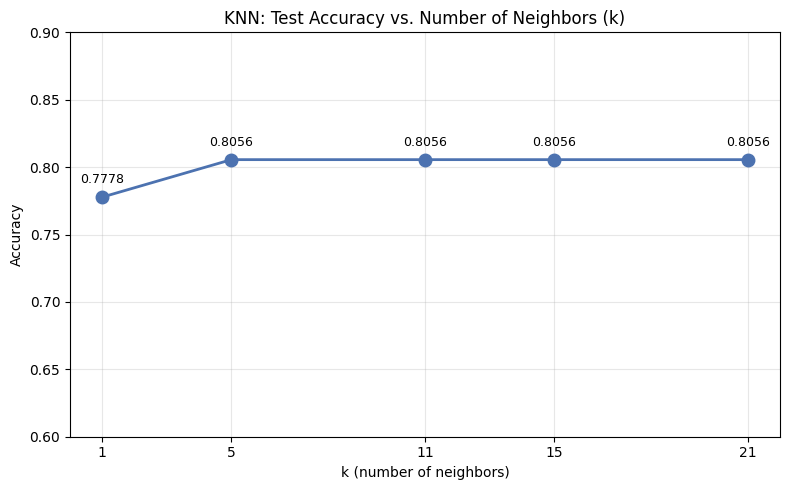

In [8]:
# Plot 1 — KNN accuracy vs k
plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_accuracies, marker='o', linewidth=2, markersize=9, color='#4C72B0')
for k, a in zip(k_values, knn_accuracies):
    plt.annotate(f'{a:.4f}', (k, a), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
plt.title('KNN: Test Accuracy vs. Number of Neighbors (k)')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.ylim(0.60, 0.90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

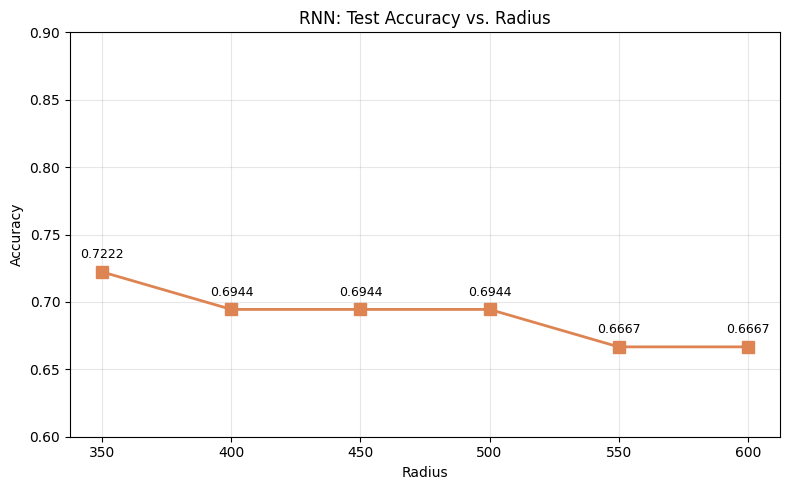

In [9]:
# Plot 2 — RNN accuracy vs radius
plt.figure(figsize=(8, 5))
plt.plot(radius_values, rnn_accuracies, marker='s', linewidth=2, markersize=9, color='#DD8452')
for r, a in zip(radius_values, rnn_accuracies):
    plt.annotate(f'{a:.4f}', (r, a), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
plt.title('RNN: Test Accuracy vs. Radius')
plt.xlabel('Radius')
plt.ylabel('Accuracy')
plt.xticks(radius_values)
plt.ylim(0.60, 0.90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

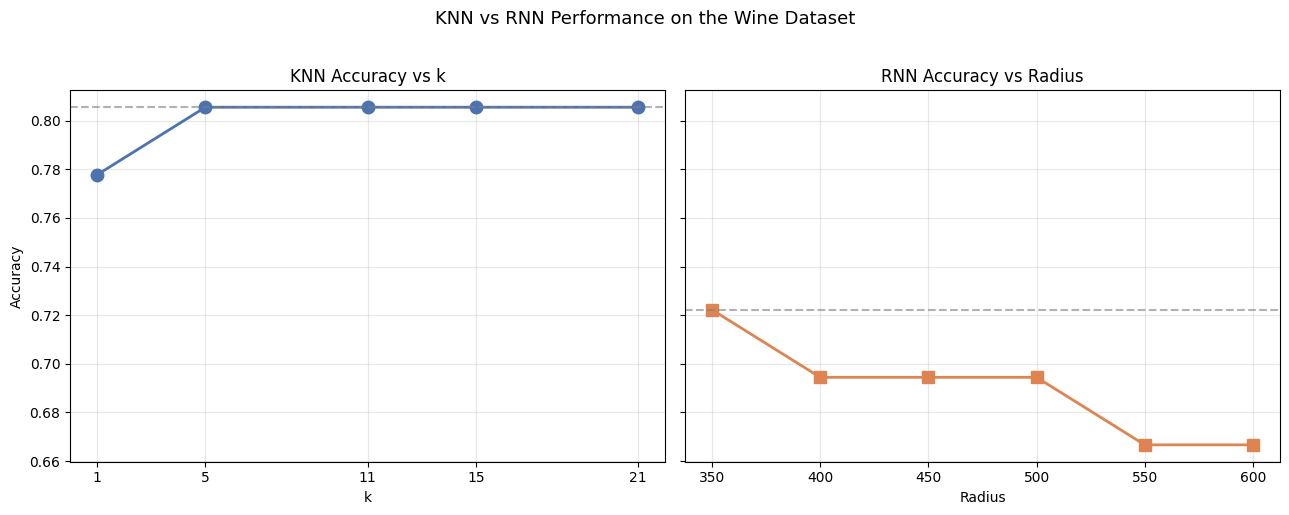

Best KNN accuracy: 0.8056 (k=5)
Best RNN accuracy: 0.7222 (radius=350)


In [10]:
# Combined comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].plot(k_values, knn_accuracies, marker='o', linewidth=2, markersize=9, color='#4C72B0')
axes[0].set_title('KNN Accuracy vs k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(k_values)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(max(knn_accuracies), ls='--', color='grey', alpha=0.6)

axes[1].plot(radius_values, rnn_accuracies, marker='s', linewidth=2, markersize=9, color='#DD8452')
axes[1].set_title('RNN Accuracy vs Radius')
axes[1].set_xlabel('Radius')
axes[1].set_xticks(radius_values)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(max(rnn_accuracies), ls='--', color='grey', alpha=0.6)

plt.suptitle('KNN vs RNN Performance on the Wine Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Best KNN accuracy: {max(knn_accuracies):.4f} (k={k_values[int(np.argmax(knn_accuracies))]})")
print(f"Best RNN accuracy: {max(rnn_accuracies):.4f} (radius={radius_values[int(np.argmax(rnn_accuracies))]})")

---
## Comparison, Observations & Discussion

### Summary of results

| Model | Best accuracy | Best parameter | Trend |
|---|---|---|---|
| **KNN** | **0.8056** | k = 5 (flat through 21) | Rises from k=1, then plateaus |
| **RNN** | 0.7222 | radius = 350 | Steadily **decreases** as radius grows |

### Observations

1. **KNN outperformed RNN at every parameter tested.** KNN's best accuracy (0.8056) beats RNN's best (0.7222). KNN adapts to local density automatically — it always finds exactly k neighbors regardless of how near or far they are — whereas RNN's fixed radius behaves very differently in dense vs. sparse regions of the feature space.

2. **KNN is stable across k; RNN is sensitive to radius.** After k = 5 the KNN accuracy is flat, showing the majority vote is robust on this dataset. RNN, in contrast, loses accuracy as the radius grows because a bigger sphere admits more far-away points from other classes, diluting the local signal.

3. **Feature scaling is the hidden story.** The Wine dataset's `proline` feature (range 278–1680) dominates Euclidean distance, which is why the meaningful radius values are in the hundreds. Neither model was given standardized features here (per the lab design); with standardization, both models would improve and the useful radius would be near ~1–3 instead of 350–600. This is an important practical lesson: **distance-based methods should normally be used with feature scaling.**

4. **k = 1 underperforms** (0.7778) because a single nearest neighbor is noise-sensitive; one mislabeled or atypical training point flips the prediction.

### When is each model preferable?

**KNN is preferable when:**
- The data density varies across the feature space (KNN self-adapts by always taking k points)
- You want a guaranteed prediction for every query point
- You have no good intuition for a meaningful distance threshold

**RNN is preferable when:**
- A physically meaningful distance threshold exists (e.g., "wines within a known chemical tolerance")
- The data density is fairly uniform
- You *want* the model to abstain (or flag low confidence) when no training points are nearby — in sparse regions RNN can raise an error/outlier signal rather than force a guess, which can be safer in high-stakes applications

**Based on these results**, KNN with k = 5 is the better choice for the Wine dataset — higher accuracy, stable behavior, and no risk of empty neighborhoods.